## Part 1: Data Collection & Database Connection

### Step 1-Generating & Populating Data
1. Connect to the Neon DB Employees table.
2. Generate 50 synthetic records using Python and the Faker library.
3. Insert the data into the Employees table.

### Data Collection

The data was sourced from a free-tier PostgreSQL database created with Neon. An `employees` table was set up with the following fields:

- `employee_id`: Unique identifier for each employee.
- `name`: Employee name.
- `position`: Employee job title.
- `start_date`: Employee start date.
- `salary`: Employee annual salary.

Because no real employee data was used, 50 synthetic records were generated with Python and the Faker library. The code randomly assigned names, job positions, start dates, and salaries, then inserted the generated records into the Neon `employees` table using Psycopg.

In [3]:
import os
import random
from datetime import date

import psycopg
from dotenv import load_dotenv
from faker import Faker

load_dotenv()

fake = Faker()

POSITIONS = [
    "Software Developer",
    "Data Analyst",
    "Data Engineer",
    "Database Administrator",
    "Cybersecurity Analyst",
    "Cloud Engineer",
    "Network Administrator",
    "IT Support Specialist",
    "Systems Administrator",
    "Project Manager",
]


def get_connection():
    database_url = os.getenv("DATABASE_URL")

    if not database_url:
        raise ValueError("DATABASE_URL is missing from .env")

    return psycopg.connect(database_url)


def generate_employees(record_count=50):
    employees = []

    for _ in range(record_count):
        employees.append(
            (
                fake.name(),
                random.choice(POSITIONS),
                fake.date_between(
                    start_date=date(2015, 1, 1),
                    end_date=date(2024, 12, 31),
                ),
                random.randint(60000, 200000),
            )
        )

    return employees


def insert_employees(record_count=50):
    employees = generate_employees(record_count)

    with get_connection() as connection:
        with connection.cursor() as cursor:
            # Start IDs after the current highest employee ID.
            cursor.execute(
                "SELECT COALESCE(MAX(employee_id), 0) FROM employees"
            )
            next_employee_id = cursor.fetchone()[0] + 1

            employee_rows = [
                (next_employee_id + index, *employee)
                for index, employee in enumerate(employees)
            ]

            cursor.executemany(
                """
                INSERT INTO employees
                    (employee_id, name, position, start_date, salary)
                VALUES
                    (%s, %s, %s, %s, %s)
                """,
                employee_rows,
            )

    print(f"Inserted {record_count} synthetic employee records.")


insert_employees(50)

Inserted 50 synthetic employee records.


### Step 2: Connect and Load Data

1. Using Python, Psycopg, and Pandas, connect to your cloud database.
2. Query the entire employee table using SQLAlchemy and load the data into a Pandas DataFrame.
3. Display the first few rows using `df.head()`.

In [7]:
import os

import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()

database_url = os.getenv("DATABASE_URL")

if not database_url:
    raise ValueError("DATABASE_URL is missing from the .env file.")

sqlalchemy_url = database_url.replace(
    "postgresql://",
    "postgresql+psycopg://",
    1,
)

engine = create_engine(sqlalchemy_url, pool_pre_ping=True)

try:
    with engine.connect() as connection:
        df = pd.read_sql_query(
            text("SELECT * FROM employees ORDER BY employee_id"),
            connection,
        )

    print(df.head())

finally:
    engine.dispose()

   employee_id                  name                position  start_date  \
0            1  Bradley Davidson DVM  Database Administrator  2021-06-21   
1            2           Tammy Allen   Systems Administrator  2024-09-24   
2            3          Joseph Brown      Software Developer  2017-08-31   
3            4           Tara Rivera      Software Developer  2022-03-18   
4            5             Todd Owen   Network Administrator  2024-10-15   

   salary  
0  120780  
1  163625  
2  187390  
3  162650  
4  123290  


## Part 2- Exploratory Data Analysis




### Data Cleaning

The employee data should be checked before analysis to make sure that each record is complete, valid, and consistent. The cleaning process checks for:

1. Missing values in required columns such as `employee_id`, `name`, `position`, `start_date`, and `salary`.
2. Duplicate rows and duplicate employee IDs.
3. Invalid employee IDs, including non-numeric or non-positive values.
4. Invalid or incorrectly formatted start dates.
5. Invalid salary values, including non-numeric or non-positive values.
6. Blank names and positions, as well as job positions outside the approved list.

The code below creates a copy of the original DataFrame, reports the detected issues, standardizes text and data types, removes records that cannot be safely used, and displays the cleaned result. The original `df` remains unchanged.

In [8]:
if "df" not in globals():
    raise NameError("Run the database query cell first so that df is available.")

cleaned_df = df.copy()

required_columns = [
    "employee_id",
    "name",
    "position",
    "start_date",
    "salary",
]

missing_columns = [
    column for column in required_columns if column not in cleaned_df.columns
]

if missing_columns:
    raise KeyError(f"Missing expected columns: {missing_columns}")

print("Initial shape:", cleaned_df.shape)
print("Missing values before cleaning:")
print(cleaned_df[required_columns].isna().sum())
print("Duplicate rows before cleaning:", cleaned_df.duplicated().sum())
print(
    "Duplicate employee IDs before cleaning:",
    cleaned_df["employee_id"].duplicated().sum(),
)

# Standardize text fields and convert typed columns safely.
cleaned_df["name"] = cleaned_df["name"].astype("string").str.strip()
cleaned_df["position"] = cleaned_df["position"].astype("string").str.strip()
cleaned_df["employee_id"] = pd.to_numeric(
    cleaned_df["employee_id"], errors="coerce"
)
cleaned_df["start_date"] = pd.to_datetime(
    cleaned_df["start_date"], errors="coerce"
)
cleaned_df["salary"] = pd.to_numeric(cleaned_df["salary"], errors="coerce")

valid_positions = {
    "Software Developer",
    "Data Analyst",
    "Data Engineer",
    "Database Administrator",
    "Cybersecurity Analyst",
    "Cloud Engineer",
    "Network Administrator",
    "IT Support Specialist",
    "Systems Administrator",
    "Project Manager",
}

invalid_position_mask = ~cleaned_df["position"].isin(valid_positions)
invalid_value_mask = (
    cleaned_df["employee_id"].isna()
    | (cleaned_df["employee_id"] <= 0)
    | cleaned_df["name"].isna()
    | cleaned_df["name"].eq("")
    | cleaned_df["position"].isna()
    | invalid_position_mask
    | cleaned_df["start_date"].isna()
    | cleaned_df["salary"].isna()
    | (cleaned_df["salary"] <= 0)
)

print("Invalid records before cleaning:", invalid_value_mask.sum())

cleaned_df = cleaned_df.loc[~invalid_value_mask].copy()
cleaned_df = cleaned_df.drop_duplicates()
cleaned_df = cleaned_df.drop_duplicates(subset="employee_id", keep="first")
cleaned_df["employee_id"] = cleaned_df["employee_id"].astype("int64")
cleaned_df["salary"] = cleaned_df["salary"].astype("int64")

print("Final shape:", cleaned_df.shape)
print("Missing values after cleaning:")
print(cleaned_df[required_columns].isna().sum())
print("Duplicate rows after cleaning:", cleaned_df.duplicated().sum())
print("Cleaned data preview:")
display(cleaned_df.head())

Initial shape: (150, 5)
Missing values before cleaning:
employee_id    0
name           0
position       0
start_date     0
salary         0
dtype: int64
Duplicate rows before cleaning: 0
Duplicate employee IDs before cleaning: 0
Invalid records before cleaning: 0
Final shape: (150, 5)
Missing values after cleaning:
employee_id    0
name           0
position       0
start_date     0
salary         0
dtype: int64
Duplicate rows after cleaning: 0
Cleaned data preview:


,employee_id,name,position,start_date,salary
0,1,Bradley Davidson DVM,Database Administrator,2021-06-21,120780
1,2,Tammy Allen,Systems Administrator,2024-09-24,163625
2,3,Joseph Brown,Software Developer,2017-08-31,187390
3,4,Tara Rivera,Software Developer,2022-03-18,162650
4,5,Todd Owen,Network Administrator,2024-10-15,123290


### Data Transformation

After cleaning, the employee data can be transformed into analysis-ready features without changing the original cleaned values. The transformation step:

1. Normalizes job titles so equivalent labels use one consistent value.
2. Extracts the start year, month, and quarter from `start_date`.
3. Converts `salary` into thousands for easier reporting.
4. Groups salaries into useful bands for comparison.
5. Calculates each employee's approximate tenure in years using the current date.

The transformed data is stored in a new `transformed_df` DataFrame so that `cleaned_df` remains available for comparison.

In [9]:
if "cleaned_df" not in globals():
    raise NameError("Run the data cleaning cell first so that cleaned_df is available.")

transformed_df = cleaned_df.copy()

# Map common variations to one canonical job-title format.
job_title_map = {
    "software developer": "Software Developer",
    "data analyst": "Data Analyst",
    "data engineer": "Data Engineer",
    "database administrator": "Database Administrator",
    "cybersecurity analyst": "Cybersecurity Analyst",
    "cloud engineer": "Cloud Engineer",
    "network administrator": "Network Administrator",
    "it support specialist": "IT Support Specialist",
    "systems administrator": "Systems Administrator",
    "project manager": "Project Manager",
}

position_key = (
    transformed_df["position"]
    .astype("string")
    .str.strip()
    .str.lower()
)
transformed_df["position_normalized"] = position_key.map(job_title_map)

# Extract calendar features from the validated start date.
transformed_df["start_year"] = transformed_df["start_date"].dt.year
transformed_df["start_month"] = transformed_df["start_date"].dt.month
transformed_df["start_quarter"] = transformed_df["start_date"].dt.quarter

# Create reporting-friendly salary features.
transformed_df["salary_k"] = (transformed_df["salary"] / 1000).round(1)
transformed_df["salary_band"] = pd.cut(
    transformed_df["salary"],
    bins=[0, 80000, 120000, 160000, float("inf")],
    labels=["Entry", "Mid", "Senior", "Executive"],
    include_lowest=True,
)

reference_date = pd.Timestamp.today().normalize()
transformed_df["tenure_years"] = (
    (reference_date - transformed_df["start_date"]).dt.days / 365.25
).round(1).clip(lower=0)

transformed_df = transformed_df.drop(columns="position_key", errors="ignore")

transformed_columns = [
    "employee_id",
    "name",
    "position",
    "position_normalized",
    "start_date",
    "start_year",
    "start_month",
    "start_quarter",
    "salary",
    "salary_k",
    "salary_band",
    "tenure_years",
]

print("Transformed shape:", transformed_df.shape)
display(transformed_df[transformed_columns].head())

Transformed shape: (150, 12)


,employee_id,name,position,position_normalized,start_date,start_year,start_month,start_quarter,salary,salary_k,salary_band,tenure_years
0,1,Bradley Davidson DVM,Database Administrator,Database Administrator,2021-06-21,2021,6,2,120780,120.8,Senior,5.3
1,2,Tammy Allen,Systems Administrator,Systems Administrator,2024-09-24,2024,9,3,163625,163.6,Executive,2.0
2,3,Joseph Brown,Software Developer,Software Developer,2017-08-31,2017,8,3,187390,187.4,Executive,9.1
3,4,Tara Rivera,Software Developer,Software Developer,2022-03-18,2022,3,1,162650,162.6,Executive,4.5
4,5,Todd Owen,Network Administrator,Network Administrator,2024-10-15,2024,10,4,123290,123.3,Senior,1.9


### Feature Engineering

Feature engineering creates new variables from the cleaned and transformed employee data to support deeper analysis. The features below are derived from existing columns rather than collected as new data:

1. `tenure_band` groups employees by years of service.
2. `position_average_salary` calculates the average salary for each normalized job title.
3. `salary_vs_position_average` shows whether an employee earns above or below their role average.
4. `salary_percentile` shows an employee's relative position in the overall salary distribution.
5. `start_cohort` groups employees by the period in which they joined.
6. `is_recent_hire` identifies employees with less than three years of service.

The engineered data is stored in `featured_df`, while `transformed_df` remains unchanged.

In [10]:
if "transformed_df" not in globals():
    raise NameError(
        "Run the data transformation cell first so that transformed_df is available."
    )

featured_df = transformed_df.copy()

# Compare each employee's salary with the average for the same job title.
featured_df["position_average_salary"] = (
    featured_df.groupby("position_normalized")["salary"]
    .transform("mean")
    .round(2)
)
featured_df["salary_vs_position_average"] = (
    featured_df["salary"] - featured_df["position_average_salary"]
).round(2)

# Add relative salary and tenure categories for grouping and visualization.
featured_df["salary_percentile"] = (
    featured_df["salary"].rank(pct=True).round(3)
)
featured_df["tenure_band"] = pd.cut(
    featured_df["tenure_years"],
    bins=[-float("inf"), 2, 5, 10, float("inf")],
    labels=["0-2 years", "3-5 years", "6-10 years", "10+ years"],
)
featured_df["start_cohort"] = pd.cut(
    featured_df["start_year"],
    bins=[-float("inf"), 2019, 2022, float("inf")],
    labels=["2019 or earlier", "2020-2022", "2023 or later"],
)
featured_df["is_recent_hire"] = featured_df["tenure_years"] < 3

feature_columns = [
    "employee_id",
    "position_normalized",
    "salary",
    "position_average_salary",
    "salary_vs_position_average",
    "salary_percentile",
    "tenure_years",
    "tenure_band",
    "start_cohort",
    "is_recent_hire",
]

print("Featured data shape:", featured_df.shape)
display(featured_df[feature_columns].head())

Featured data shape: (150, 18)


,employee_id,position_normalized,salary,position_average_salary,salary_vs_position_average,salary_percentile,tenure_years,tenure_band,start_cohort,is_recent_hire
0,1,Database Administrator,120780,135594.00,-14814.00,0.447,5.3,6-10 years,2020-2022,False
1,2,Systems Administrator,163625,116029.56,47595.44,0.740,2.0,0-2 years,2023 or later,True
2,3,Software Developer,187390,141120.87,46269.13,0.907,9.1,6-10 years,2019 or earlier,False
3,4,Software Developer,162650,141120.87,21529.13,0.733,4.5,3-5 years,2020-2022,False
4,5,Network Administrator,123290,124159.50,-869.50,0.467,1.9,0-2 years,2023 or later,True


### Scaling and Normalization

Scaling puts numeric features on comparable ranges, which is useful for distance-based analysis, clustering, and machine-learning models. Salary values are much larger than tenure values, so using the raw columns together could give salary disproportionate influence.

This step applies two common approaches to the numeric employee features:

1. **Min-max normalization** converts values to a range from 0 to 1.
2. **Z-score standardization** centers values around 0 and scales them by their standard deviation.

The original numeric columns are retained, and the scaled values are added with `_minmax` and `_zscore` suffixes. The result is stored in `scaled_df`.

In [5]:
if "featured_df" not in globals():
    raise NameError(
        "Run the feature engineering cell first so that featured_df is available."
    )

scaled_df = featured_df.copy()

numeric_features = [
    "salary",
    "position_average_salary",
    "salary_vs_position_average",
    "tenure_years",
]

missing_numeric_features = [
    column for column in numeric_features if column not in scaled_df.columns
]

if missing_numeric_features:
    raise KeyError(f"Missing numeric features: {missing_numeric_features}")

feature_values = scaled_df[numeric_features].astype(float)
feature_minimums = feature_values.min()
feature_ranges = feature_values.max() - feature_minimums
feature_ranges = feature_ranges.mask(feature_ranges == 0, 1)

# Min-max normalization: values are mapped to the range [0, 1].
minmax_values = (feature_values - feature_minimums) / feature_ranges
minmax_values.columns = [f"{column}_minmax" for column in numeric_features]

# Z-score standardization: values are centered at 0 with unit variance.
feature_means = feature_values.mean()
feature_standard_deviations = feature_values.std(ddof=0).mask(
    lambda values: values == 0,
    1,
)
zscore_values = (
    (feature_values - feature_means) / feature_standard_deviations
)
zscore_values.columns = [f"{column}_zscore" for column in numeric_features]

scaled_df = pd.concat(
    [scaled_df, minmax_values, zscore_values],
    axis=1,
)

scaled_columns = [
    "employee_id",
    "salary",
    "salary_minmax",
    "salary_zscore",
    "tenure_years",
    "tenure_years_minmax",
    "tenure_years_zscore",
]

print("Scaled data shape:", scaled_df.shape)
display(scaled_df[scaled_columns].head())

Scaled data shape: (150, 26)


,employee_id,salary,salary_minmax,salary_zscore,tenure_years,tenure_years_minmax,tenure_years_zscore
0,1,120780,0.434421,-0.225420,5.3,0.36,-0.416448
1,2,163625,0.742218,0.846263,2.0,0.03,-1.581089
2,3,187390,0.912945,1.440697,9.1,0.74,0.924655
3,4,162650,0.735214,0.821875,4.5,0.28,-0.698785
4,5,123290,0.452453,-0.162637,1.9,0.02,-1.616381


## Descriptive Statistics

Descriptive statistics provide a numerical summary of the employee dataset and help identify patterns, unusual values, and differences between job roles.

The analysis uses common Pandas functions:

1. `info()` displays the DataFrame structure, column names, data types, and non-null counts.
2. `describe()` calculates count, mean, standard deviation, minimum, quartiles, and maximum for numeric columns.
3. `isnull().sum()` counts missing values in each column and across the complete dataset.
4. `sum()` calculates totals such as total payroll and the sum of numeric features.
5. Grouping and aggregation summarize salary and tenure by normalized job title.

These summaries use `featured_df`, which contains the cleaned, transformed, and engineered employee data.

In [11]:
if "featured_df" not in globals():
    raise NameError(
        "Run the feature engineering cell first so that featured_df is available."
    )

numeric_columns = [
    "salary",
    "position_average_salary",
    "salary_vs_position_average",
    "salary_percentile",
    "tenure_years",
]
categorical_columns = [
    "position_normalized",
    "salary_band",
    "tenure_band",
    "start_cohort",
    "is_recent_hire",
]

print("Dataset shape:", featured_df.shape)
print("Dataset information:")
featured_df.info()

missing_values = featured_df.isnull().sum()
print("Missing values by column:")
display(missing_values.to_frame(name="missing_count"))
print("Total missing values:", int(missing_values.sum()))

print("Numeric descriptive statistics:")
numeric_summary = featured_df[numeric_columns].describe().T.round(2)
display(numeric_summary)

print("Numeric column totals:")
numeric_totals = featured_df[numeric_columns].sum().round(2)
display(numeric_totals.to_frame(name="total"))
print("Total payroll:", f"${featured_df['salary'].sum():,.2f}")

print("Categorical descriptive statistics:")
categorical_summary = featured_df[categorical_columns].describe().T
display(categorical_summary)

print("Start date range:")
print("Earliest start date:", featured_df["start_date"].min().date())
print("Latest start date:", featured_df["start_date"].max().date())

print("Employee counts by normalized job title:")
position_counts = (
    featured_df["position_normalized"]
    .value_counts()
    .rename_axis("position_normalized")
    .reset_index(name="employee_count")
)
display(position_counts)

print("Salary and tenure summary by normalized job title:")
position_summary = (
    featured_df.groupby("position_normalized", as_index=False)
    .agg(
        employee_count=("employee_id", "count"),
        average_salary=("salary", "mean"),
        median_salary=("salary", "median"),
        average_tenure_years=("tenure_years", "mean"),
    )
    .sort_values("average_salary", ascending=False)
)
position_summary[["average_salary", "median_salary", "average_tenure_years"]] = (
    position_summary[
        ["average_salary", "median_salary", "average_tenure_years"]
    ].round(2)
)
display(position_summary)

Dataset shape: (150, 18)
Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype        
---  ------                      --------------  -----        
 0   employee_id                 150 non-null    int64        
 1   name                        150 non-null    string       
 2   position                    150 non-null    string       
 3   start_date                  150 non-null    datetime64[s]
 4   salary                      150 non-null    int64        
 5   position_normalized         150 non-null    str          
 6   start_year                  150 non-null    int32        
 7   start_month                 150 non-null    int32        
 8   start_quarter               150 non-null    int32        
 9   salary_k                    150 non-null    float64      
 10  salary_band                 150 non-null    category     
 11  tenure_years                150 non-

,missing_count
employee_id,0
name,0
position,0
start_date,0
salary,0
position_normalized,0
start_year,0
start_month,0
start_quarter,0
salary_k,0


Total missing values: 0
Numeric descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
salary,150.0,129792.11,40113.12,60309.00,95157.00,132488.00,163895.50,199508.00
position_average_salary,150.0,129792.11,7027.31,116029.56,124159.50,132888.79,134324.09,141120.87
salary_vs_position_average,150.0,-0.00,39492.77,-80811.87,-31835.00,1504.25,30735.81,73953.00
salary_percentile,150.0,0.50,0.29,0.01,0.25,0.50,0.75,1.00
tenure_years,150.0,6.48,2.84,1.70,4.03,6.30,9.00,11.70


Numeric column totals:


...

,count,unique,top,freq
position_normalized,150,10,Cybersecurity Analyst,23
salary_band,150,4,Mid,46
tenure_band,150,4,6-10 years,73
start_cohort,150,3,2019 or earlier,65
is_recent_hire,150,2,False,134


Start date range:
Earliest start date: 2015-01-09
Latest start date: 2024-12-24
Employee counts by normalized job title:


,position_normalized,employee_count
0,Cybersecurity Analyst,23
1,Cloud Engineer,21
2,Database Administrator,18
3,Network Administrator,16
4,Software Developer,15
5,Data Engineer,14
6,Data Analyst,13
7,Project Manager,12
8,Systems Administrator,9
9,IT Support Specialist,9


Salary and tenure summary by normalized job title:


,position_normalized,employee_count,average_salary,median_salary,average_tenure_years
8,Software Developer,15,141120.87,150854.0,6.40
4,Database Administrator,18,135594.00,141818.5,6.67
1,Cybersecurity Analyst,23,134324.09,150248.0,6.48
2,Data Analyst,13,133159.69,140094.0,6.35
3,Data Engineer,14,132888.79,138223.0,5.79
7,Project Manager,12,126943.17,110673.0,7.07
5,IT Support Specialist,9,126339.00,127835.0,6.07
6,Network Administrator,16,124159.50,120826.5,5.44
0,Cloud Engineer,21,120912.00,110699.0,7.43
9,Systems Administrator,9,116029.56,132159.0,6.76


## Part 3: Visualization Challenges

### 1. Standard Visualization

A grouped bar chart is used to compare the average salary for each position across employee start years. Each group represents a start year, and each bar within the group represents a normalized job position. This makes it possible to compare salary patterns across both dimensions.

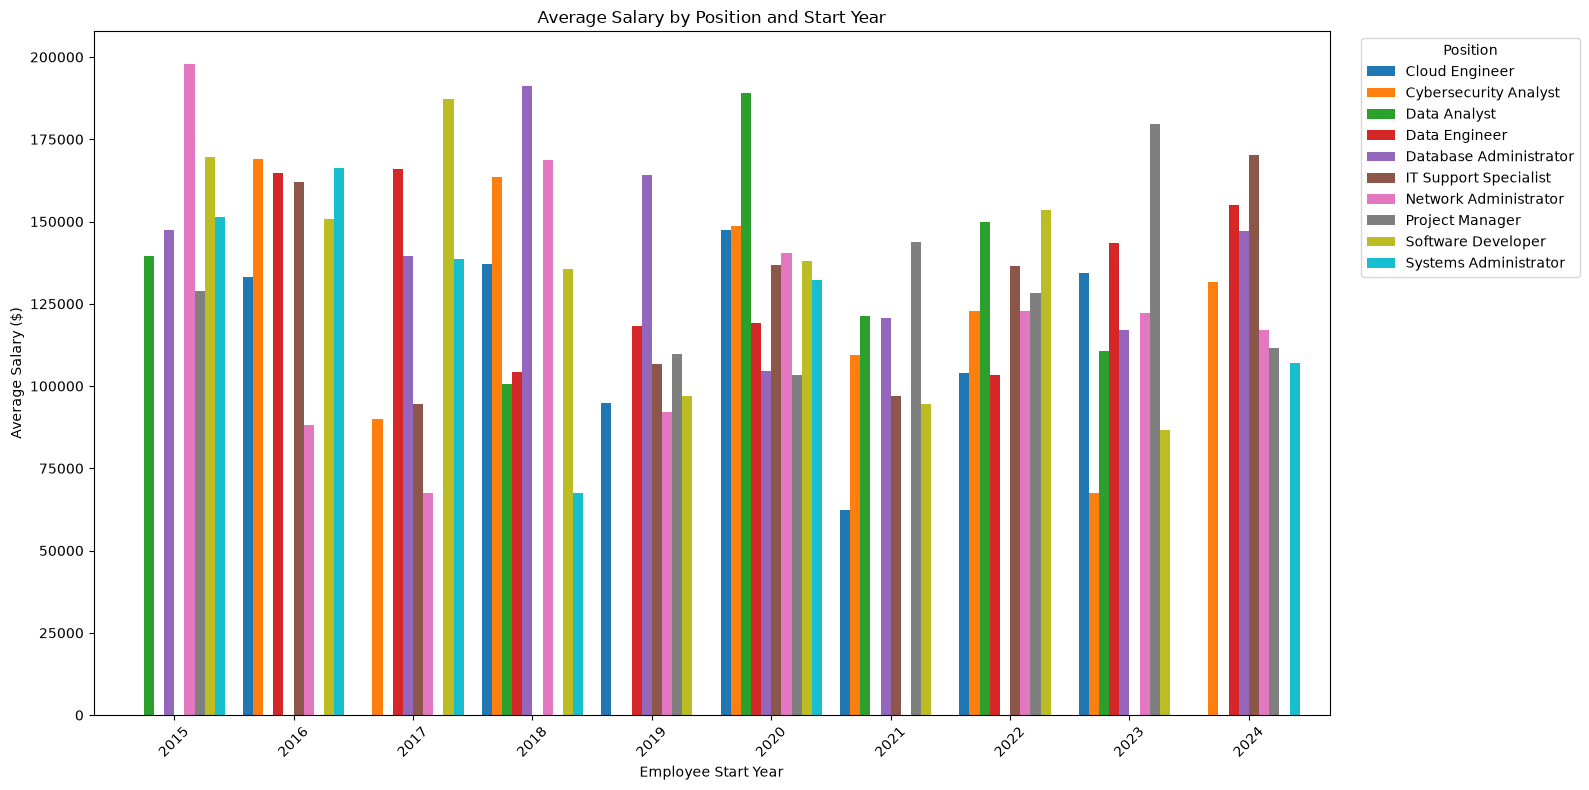

,start_year,position_normalized,salary
0,2015,Data Analyst,139456.00
1,2015,Database Administrator,147521.00
2,2015,Network Administrator,197907.00
3,2015,Project Manager,128814.25
4,2015,Software Developer,169675.00
5,2015,Systems Administrator,151280.00
6,2016,Cloud Engineer,133245.50
7,2016,Cybersecurity Analyst,169057.80
8,2016,Data Engineer,164848.00
9,2016,IT Support Specialist,162060.00


In [5]:
if "featured_df" not in globals():
    raise NameError(
        "Run the feature engineering cell first so that featured_df is available."
    )

import matplotlib.pyplot as plt

average_salary_by_position_year = (
    featured_df.groupby(
        ["start_year", "position_normalized"],
        as_index=False,
    )["salary"]
    .mean()
)

salary_chart_data = average_salary_by_position_year.pivot(
    index="start_year",
    columns="position_normalized",
    values="salary",
)

ax = salary_chart_data.plot(
    kind="bar",
    figsize=(16, 8),
    width=0.85,
)
ax.set_title("Average Salary by Position and Start Year")
ax.set_xlabel("Employee Start Year")
ax.set_ylabel("Average Salary ($)")
ax.legend(title="Position", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(average_salary_by_position_year.head(10))

### 2. Advanced Visualization Challenge: Database Joins

This section extends the original Neon database instead of creating temporary in-memory tables.

1. Create a `departments` table containing the department name, location, and annual budget.
2. Create a `project_assignments` table containing the employee, project, assignment year, and project role.
3. Populate both tables with additional analysis data using SQLAlchemy and Psycopg.
4. Link `project_assignments.employee_id` to `employees.employee_id` and join the three tables.
5. Fetch the joined records from Neon into a Pandas DataFrame.
6. Use the fetched data to create a department-position salary heatmap and a salary-versus-tenure scatter plot with a trendline.

#### How the Additional Tables Are Populated

- **Departments:** The code defines five sample department records in Python. Each record includes a department name, location, and positive annual budget. These rows are inserted into Neon with a parameterized SQL `INSERT` statement.
- **Project assignments:** The code first reads every `employee_id` and `position` from the Neon `employees` table. It then assigns each employee a project, assignment year, and project role. The project role comes from the employee's existing position, while the project is selected from the sample project list. These generated rows are inserted into `project_assignments` using the employee ID as the foreign-key link.
- **Database relationships:** `departments.department` is the primary key, and `project_assignments.employee_id` references `employees.employee_id`. The employee position is mapped to its department when the three tables are joined.
- **Rerunning the code:** Both supporting tables are created only if they do not already exist. Within one transaction, their existing sample rows are deleted and repopulated, while the original `employees` table is left unchanged. This prevents duplicate project assignments when the notebook cell is run again.

The final SQL query fetches employee, department, budget, location, project, salary, and start-date information from Neon for the visualizations.

Departments table fetched from Neon:


,department,location,annual_budget
0,Corporate PMO,Toronto,1200000.0
1,Cybersecurity,Montreal,1400000.0
2,Data & Analytics,Waterloo,1800000.0
3,Engineering,Toronto,2500000.0
4,IT Operations,Ottawa,1600000.0


Project assignments fetched from Neon:


,employee_id,project_name,assignment_year,project_role
0,1,Data Platform Upgrade,2025,Database Administrator
1,2,Security Modernization,2024,Systems Administrator
2,3,Network Refresh,2025,Software Developer
3,4,Employee Portal,2024,Software Developer
4,5,Cloud Migration,2025,Network Administrator


Joined employee, department, and project records:


,employee_id,name,position,start_date,salary,department,location,annual_budget,project_name,assignment_year,project_role,start_year,tenure_years,position_normalized
0,1,Bradley Davidson DVM,Database Administrator,2021-06-21,120780,IT Operations,Ottawa,1600000.0,Data Platform Upgrade,2025,Database Administrator,2021,5.3,Database Administrator
1,2,Tammy Allen,Systems Administrator,2024-09-24,163625,IT Operations,Ottawa,1600000.0,Security Modernization,2024,Systems Administrator,2024,2.0,Systems Administrator
2,3,Joseph Brown,Software Developer,2017-08-31,187390,Engineering,Toronto,2500000.0,Network Refresh,2025,Software Developer,2017,9.1,Software Developer
3,4,Tara Rivera,Software Developer,2022-03-18,162650,Engineering,Toronto,2500000.0,Employee Portal,2024,Software Developer,2022,4.5,Software Developer
4,5,Todd Owen,Network Administrator,2024-10-15,123290,IT Operations,Ottawa,1600000.0,Cloud Migration,2025,Network Administrator,2024,1.9,Network Administrator


Salary and tenure distribution by project:


,project_name,department,employee_count,average_salary,average_tenure_years
22,Security Modernization,Engineering,10,161057.40,6.82
16,Network Refresh,Data & Analytics,4,157516.25,6.95
15,Network Refresh,Cybersecurity,6,147591.17,6.87
10,Employee Portal,Cybersecurity,6,138668.50,5.42
18,Network Refresh,IT Operations,6,135229.17,7.17
5,Data Platform Upgrade,Cybersecurity,4,134069.75,7.98
19,Security Modernization,Corporate PMO,5,133640.80,7.98
9,Employee Portal,Corporate PMO,2,133354.00,7.15
3,Cloud Migration,IT Operations,17,132799.29,6.13
0,Cloud Migration,Cybersecurity,3,132735.67,7.03


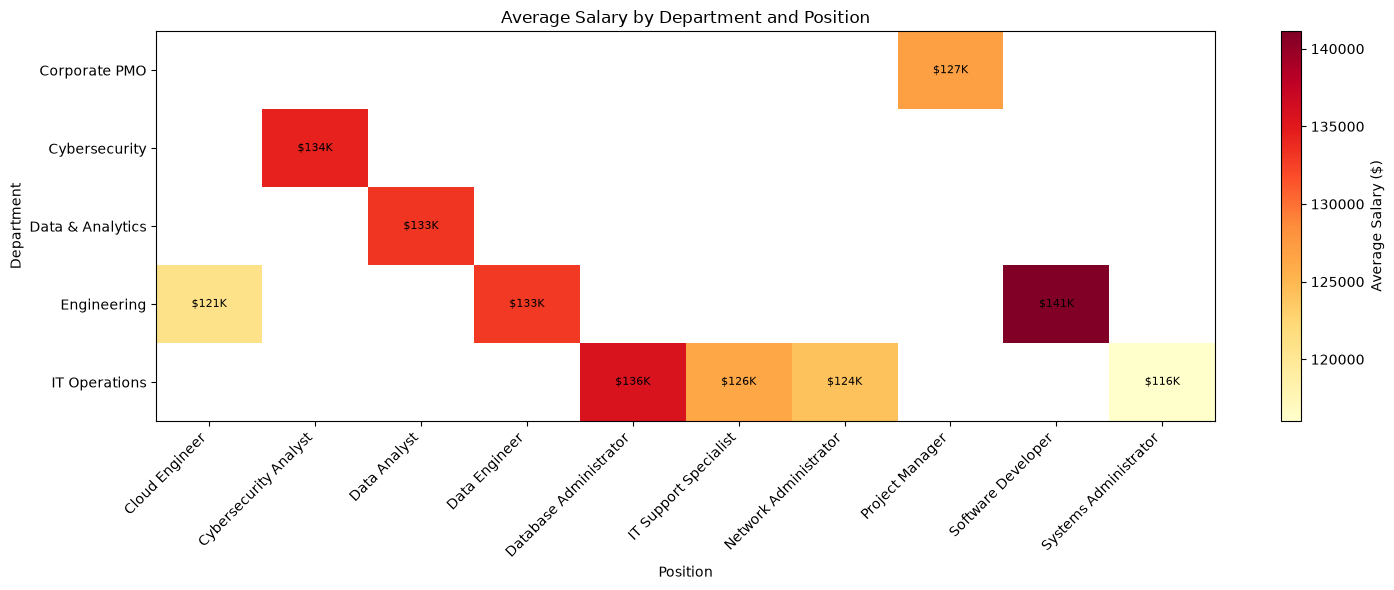

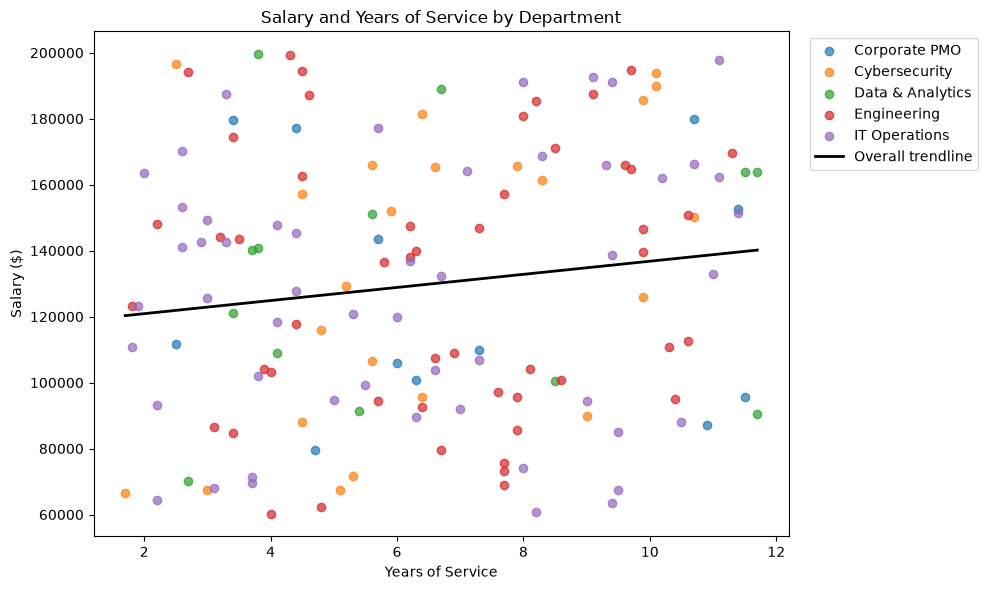

In [13]:
if "featured_df" not in globals():
    raise NameError(
        "Run the feature engineering cell first so that featured_df is available."
    )

import matplotlib.pyplot as plt
import numpy as np
from sqlalchemy import create_engine, text

load_dotenv()
database_url = os.getenv("DATABASE_URL")

if not database_url:
    raise ValueError("DATABASE_URL is missing from the .env file.")

sqlalchemy_url = database_url.replace(
    "postgresql://",
    "postgresql+psycopg://",
    1,
)
engine = create_engine(sqlalchemy_url, pool_pre_ping=True)

department_rows = [
    {"department": "Engineering", "location": "Toronto", "annual_budget": 2500000},
    {"department": "Data & Analytics", "location": "Waterloo", "annual_budget": 1800000},
    {"department": "IT Operations", "location": "Ottawa", "annual_budget": 1600000},
    {"department": "Cybersecurity", "location": "Montreal", "annual_budget": 1400000},
    {"department": "Corporate PMO", "location": "Toronto", "annual_budget": 1200000},
]

position_department_map = {
    "Software Developer": "Engineering",
    "Data Engineer": "Engineering",
    "Cloud Engineer": "Engineering",
    "Data Analyst": "Data & Analytics",
    "Database Administrator": "IT Operations",
    "Network Administrator": "IT Operations",
    "Systems Administrator": "IT Operations",
    "IT Support Specialist": "IT Operations",
    "Cybersecurity Analyst": "Cybersecurity",
    "Project Manager": "Corporate PMO",
}
project_names = [
    "Cloud Migration",
    "Data Platform Upgrade",
    "Security Modernization",
    "Network Refresh",
    "Employee Portal",
]

try:
    with engine.begin() as connection:
        connection.execute(
            text("""
                CREATE TABLE IF NOT EXISTS departments (
                    department VARCHAR(100) PRIMARY KEY,
                    location VARCHAR(100) NOT NULL,
                    annual_budget NUMERIC(12, 2) NOT NULL CHECK (annual_budget > 0)
                )
            """)
        )
        connection.execute(
            text("""
                CREATE TABLE IF NOT EXISTS project_assignments (
                    assignment_id SERIAL PRIMARY KEY,
                    employee_id INTEGER NOT NULL REFERENCES employees(employee_id),
                    project_name VARCHAR(100) NOT NULL,
                    assignment_year INTEGER NOT NULL,
                    project_role VARCHAR(100) NOT NULL
                )
            """)
        )
        connection.execute(text("DELETE FROM project_assignments"))
        connection.execute(text("DELETE FROM departments"))
        connection.execute(
            text("""
                INSERT INTO departments (department, location, annual_budget)
                VALUES (:department, :location, :annual_budget)
            """),
            department_rows,
        )
        employee_records = connection.execute(
            text("SELECT employee_id, position FROM employees ORDER BY employee_id")
        ).mappings().all()
        project_rows = [
            {
                "employee_id": record["employee_id"],
                "project_name": project_names[
                    record["employee_id"] % len(project_names)
                ],
                "assignment_year": 2024 + (record["employee_id"] % 2),
                "project_role": record["position"],
            }
            for record in employee_records
        ]
        connection.execute(
            text("""
                INSERT INTO project_assignments
                    (employee_id, project_name, assignment_year, project_role)
                VALUES (:employee_id, :project_name, :assignment_year, :project_role)
            """),
            project_rows,
        )

    with engine.connect() as connection:
        departments = pd.read_sql_query(
            text("SELECT * FROM departments ORDER BY department"), connection
        )
        project_assignments = pd.read_sql_query(
            text("""
                SELECT employee_id, project_name, assignment_year, project_role
                FROM project_assignments
                ORDER BY employee_id
            """),
            connection,
        )
        project_employee_data = pd.read_sql_query(
            text("""
                SELECT
                    e.employee_id, e.name, e.position, e.start_date, e.salary,
                    d.department, d.location, d.annual_budget,
                    p.project_name, p.assignment_year, p.project_role
                FROM employees AS e
                INNER JOIN project_assignments AS p
                    ON p.employee_id = e.employee_id
                INNER JOIN departments AS d
                    ON d.department = CASE e.position
                        WHEN 'Software Developer' THEN 'Engineering'
                        WHEN 'Data Engineer' THEN 'Engineering'
                        WHEN 'Cloud Engineer' THEN 'Engineering'
                        WHEN 'Data Analyst' THEN 'Data & Analytics'
                        WHEN 'Database Administrator' THEN 'IT Operations'
                        WHEN 'Network Administrator' THEN 'IT Operations'
                        WHEN 'Systems Administrator' THEN 'IT Operations'
                        WHEN 'IT Support Specialist' THEN 'IT Operations'
                        WHEN 'Cybersecurity Analyst' THEN 'Cybersecurity'
                        WHEN 'Project Manager' THEN 'Corporate PMO'
                    END
                ORDER BY e.employee_id
            """),
            connection,
        )
finally:
    engine.dispose()

project_employee_data["start_date"] = pd.to_datetime(
    project_employee_data["start_date"]
)
project_employee_data["start_year"] = project_employee_data["start_date"].dt.year
project_employee_data["tenure_years"] = (
    (pd.Timestamp.today().normalize() - project_employee_data["start_date"]).dt.days
    / 365.25
).round(1).clip(lower=0)
project_employee_data["position_normalized"] = (
    project_employee_data["position"].astype("string").str.strip()
)

print("Departments table fetched from Neon:")
display(departments)
print("Project assignments fetched from Neon:")
display(project_assignments.head())
print("Joined employee, department, and project records:")
display(project_employee_data.head())

project_summary = (
    project_employee_data.groupby(["project_name", "department"], as_index=False)
    .agg(
        employee_count=("employee_id", "count"),
        average_salary=("salary", "mean"),
        average_tenure_years=("tenure_years", "mean"),
    )
    .sort_values("average_salary", ascending=False)
)
project_summary[["average_salary", "average_tenure_years"]] = (
    project_summary[["average_salary", "average_tenure_years"]].round(2)
)
print("Salary and tenure distribution by project:")
display(project_summary)

heatmap_data = project_employee_data.pivot_table(
    index="department",
    columns="position_normalized",
    values="salary",
    aggfunc="mean",
)
fig, ax = plt.subplots(figsize=(15, 6))
heatmap_image = ax.imshow(heatmap_data, aspect="auto", cmap="YlOrRd")
ax.set_title("Average Salary by Department and Position")
ax.set_xlabel("Position")
ax.set_ylabel("Department")
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
for row_index in range(heatmap_data.shape[0]):
    for column_index in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[row_index, column_index]
        if pd.notna(value):
            ax.text(
                column_index, row_index, f"${value / 1000:.0f}K",
                ha="center", va="center", fontsize=8,
            )
fig.colorbar(heatmap_image, ax=ax, label="Average Salary ($)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
for department, department_data in project_employee_data.groupby("department"):
    ax.scatter(
        department_data["tenure_years"],
        department_data["salary"],
        alpha=0.7,
        label=department,
    )
trendline_coefficients = np.polyfit(
    project_employee_data["tenure_years"],
    project_employee_data["salary"],
    1,
)
trendline_x = np.linspace(
    project_employee_data["tenure_years"].min(),
    project_employee_data["tenure_years"].max(),
    100,
)
trendline_y = np.polyval(trendline_coefficients, trendline_x)
ax.plot(
    trendline_x, trendline_y, color="black", linewidth=2, label="Overall trendline"
)
ax.set_title("Salary and Years of Service by Department")
ax.set_xlabel("Years of Service")
ax.set_ylabel("Salary ($)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 3. Main Insights

#### Standard Visualization: Average Salary by Position and Start Year

- Average salary varies substantially between positions within the same start year.
- Some positions have higher average salaries in particular years, but the pattern is not consistently increasing or decreasing over time.
- The number of employees in each position-year combination is different, so averages based on fewer employees should be interpreted carefully.
- The grouped bar chart is useful for comparing salary differences across both job position and hiring year.

#### Advanced Visualization: Departments and Projects

- The heatmap shows that average salary differs across departments and positions. For example, Software Developer roles in Engineering have one of the highest average salary values in the joined data.
- IT Operations contains several positions, making it useful for comparing salary differences within one department.
- The project summary shows that project salary distributions vary. Security Modernization has a high average salary for some department assignments, while smaller groups can produce less stable averages.
- The scatter plot shows a slight positive overall trend between years of service and salary, but the points are widely spread. This indicates that tenure alone does not explain salary differences; position and department are also important factors.

These findings are based on synthetic employee data generated for this exercise. They demonstrate the analysis workflow but should not be treated as conclusions about a real organization.